In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd


device = "cuda" if torch.cuda.is_available() else "cpu"

# where my preprocessed NSD files live
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
data_folder = os.path.join(nsd_path, 'data')
labels_folder = os.path.join(nsd_path, 'labels')
stim_folder = os.path.join(nsd_path, 'stimuli')
rois_folder = os.path.join(nsd_path, 'rois')

# where the model fits are saved and loaded from:
save_fits_folder = '/lab_data/hendersonlab/projects/eccbias/model_fits/'

sys.path.append('/lab_data/hendersonlab/code/utils/')
import stats_utils

In [2]:
fig_path = '/lab_data/hendersonlab/projects/eccbias/figures/'
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

In [3]:
subjects = np.arange(1, 9)
# subjects = [1]

model_names = ['resnet18-Baseline_concat', \
               'resnet18-FoveaGaze_concat', \
               'resnet18-PeriphNonTTM_concat', \
               'resnet18-PeriphTTM_concat']

model_names_short = ['Baseline',\
                     'Fovea-Gaze',\
                     'Periph',\
                     'Periph-NF']

fits = dict([])

for name in model_names:

    fits[name] = dict([])

    for si, ss in enumerate(subjects):

        name_short = name.split('_block')[0]
        name_short = name_short.split('_concat')[0]
        save_folder = os.path.join(save_fits_folder, name_short)
        filename = os.path.join(save_folder, 'NSD_S%d_%s.npy'%(ss, name))
        print(filename)
        readable_time = datetime.fromtimestamp(os.path.getmtime(filename)).strftime('%B %d, %Y at %I:%M %p')
        print(f"Last modified: {readable_time}")
        out = np.load(filename, allow_pickle=True).item()
        
        voxel_mask = out['voxel_mask']
    
        fits[name][ss] = out

/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S1_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 09:27 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S2_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:55 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S3_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:56 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S4_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:57 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S5_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:58 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S6_resnet18-Baseline_concat.npy
Last modified: February 08, 2026 at 10:59 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/resnet18-Baseline/NSD_S7_resnet18-Baseline_concat

In [7]:
vox_floc_tstats = dict([])
for subject in subjects:
    # load the pRF estimates (see "proc_rois.py")
    fn = os.path.join(rois_folder, 'S%d_floc_tstats.npy'%subject)
    tstats = np.load(fn, allow_pickle=True).item()
    vox_floc_tstats[subject] = tstats

In [8]:
sys.path.append('/lab_data/hendersonlab/code/feature_extraction/')
import prf_utils

# where my preprocessed NSD files live
# this is where we have the pre-computed pRF estimates for each voxel, for each subject
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
rois_folder = os.path.join(nsd_path, 'rois')

vox_prfs = dict([])

for ss in subjects:

    vox_prfs[ss] = dict([])
    
    # load the pRF estimates (see "proc_rois.py")
    fn = os.path.join(rois_folder, 'S%d_prf_params.npy'%ss)
    prf_info = np.load(fn, allow_pickle=True).item()
    
    # units of degrees
    a = prf_info['angle']
    e = prf_info['eccen']
    s = prf_info['size']
    
    # Converting them into [x, y] coordinates, from polar
    # The units here are degrees visual angle
    x_mapping, y_mapping = prf_utils.pol_to_cart(a,e)
    
    # this step is taking out any extreme values, way outside the image range.
    # 7 is the max extent of the pRF grid in x,y (0.8333 * 8.4)
    x_mapping = np.minimum(np.maximum(x_mapping, -7), 7)
    y_mapping = np.minimum(np.maximum(y_mapping, -7), 7)
    
    e_mapping = np.minimum(e, 7)
    # S = pRF size, sigma of the Gaussian function. Degrees visual angle.
    # again taking out any huge values here. 8.4 is max degrees of pRF grid.
    s_mapping = np.minimum(s, 8.4)

    vox_prfs[ss]['ecc'] = e_mapping
    vox_prfs[ss]['size'] = s_mapping
    vox_prfs[ss]['polarang'] = a
    vox_prfs[ss]['x_pos'] = x_mapping
    vox_prfs[ss]['y_pos'] = y_mapping
    


In [9]:
# Load info about rois and voxels in the data
rinfo_allsubs = dict([])

for si, ss in enumerate(subjects):
        
    fn = os.path.join(rois_folder, 'S%d_voxel_roi_info.npy'%ss)
    rinfo = np.load(fn, allow_pickle=True).item()
    rinfo_allsubs[ss] = rinfo

def get_roi_vox(ss, roi_name = 'FFA-2', floc_thresh=None):

    rinfo = rinfo_allsubs[ss]
    voxel_mask = rinfo['voxel_mask']
    
    all_ret_names = (list(rinfo['ret_prf_roi_names'].keys()) + ['V1','V2','V3'])
    all_place_names = (list(rinfo['floc_place_roi_names'].keys()))
    all_face_names = (list(rinfo['floc_face_roi_names'].keys()) + ['FFA'])
    all_body_names = (list(rinfo['floc_body_roi_names'].keys()) + ['FBA'])
    all_word_names = (list(rinfo['floc_word_roi_names'].keys()) + ['VWFA'])

    if roi_name in all_ret_names:
        if np.isin(roi_name, ['V1','V2','V3']):
            dorsal_name = '%sd'%roi_name
            ventral_name = '%sv'%roi_name
            ind_num = [rinfo['ret_prf_roi_names'][dorsal_name], rinfo['ret_prf_roi_names'][ventral_name]]
        else:
            ind_num = [rinfo['ret_prf_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_retino'][voxel_mask], ind_num)

    elif roi_name in all_face_names:
        if np.isin(roi_name, ['FFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_face_roi_names'][name1], rinfo['floc_face_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_face_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_face'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['faces']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_place_names:
        ind_num = rinfo['floc_place_roi_names'][roi_name]
        roi_inds = rinfo['roi_labels_place'][voxel_mask]==ind_num

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['places']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_body_names:
        if np.isin(roi_name, ['FBA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_body_roi_names'][name1], rinfo['floc_body_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_body_roi_names'][roi_name]]
        
        roi_inds = np.isin(rinfo['roi_labels_body'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['bodies']
            roi_inds = roi_inds & (t>floc_thresh)

    
    elif roi_name in all_word_names:
        if np.isin(roi_name, ['VWFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_word_roi_names'][name1], rinfo['floc_word_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_word_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_word'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['characters']
            roi_inds = roi_inds & (t>floc_thresh)

    elif roi_name=='IPS':
        # concatenate IPS0-5 here
        all_kastner_names = rinfo['kastner_atlas_roi_names'].keys()
        ips_subregions = [k for k in all_kastner_names if 'IPS' in k]
        inds_num = [rinfo['kastner_atlas_roi_names'][k] for k in ips_subregions]
        roi_inds = np.isin(rinfo['roi_labels_kastner'][voxel_mask], inds_num)

    return roi_inds


In [10]:
roi_names = ['V1','V2','V3','hV4',\
             'OFA','FFA','OWFA','VWFA', \
             'OPA','PPA','RSC']

n_rois = len(roi_names)
n_subjects = len(subjects)
n_models = len(model_names)

avg_vals = np.zeros((n_subjects, n_rois, n_models))

avg_nc =  np.zeros((n_subjects, n_rois))

for si, ss in enumerate(subjects):
        
    for mi, name in enumerate(model_names):
    
        r2 = fits[name][ss]['r2']
        nc = fits[name][ss]['voxel_nc']/100
    
        above_thresh = nc > 0.10

        for ri, roi_name in enumerate(roi_names):
    
            roi_inds = get_roi_vox(ss, roi_name = roi_name, floc_thresh = 2)
            
            vals = r2[roi_inds & above_thresh]

            avg_vals[si, ri, mi] = np.mean(vals)

            avg_nc[si, ri] = np.mean(nc[roi_inds & above_thresh])

    

In [11]:
# Plotting parameters and color definitions
project_root = '/lab_data/hendersonlab/projects/eccbias/'

figpath = os.path.join(project_root, 'figures')
if not os.path.exists(figpath):
    os.makedirs(figpath)
plt.rcParams['pdf.fonttype']=42

# exp_colors = cm.viridis(np.linspace(0, 1, 5))[0:4,:]
exp_colors = cm.tab10(np.linspace(0, 1, 10))[0:4,:]

comp_color = cm.gray(np.linspace(0, 1, 3))[1:2,:]

cond_colors = np.concatenate([exp_colors, comp_color], axis=0)

/lab_data/hendersonlab/projects/eccbias/figures/R2_allmodels_bars.pdf


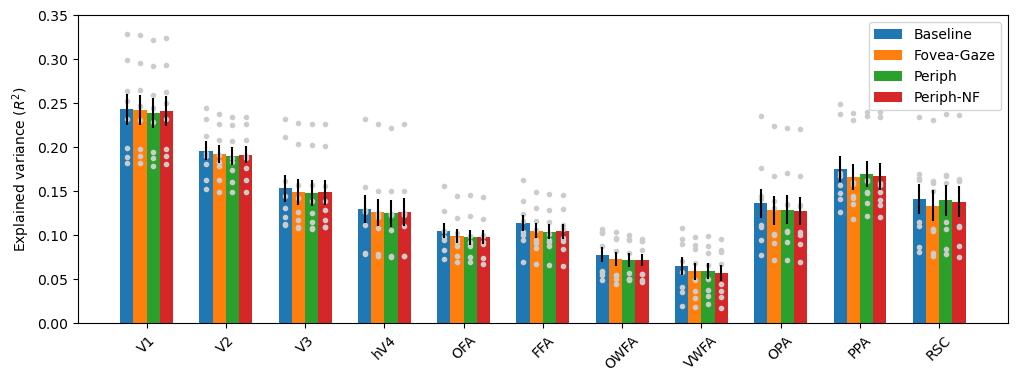

In [12]:
models_plot = [0,1,2,3]

jitters = np.linspace(-0.25, 0.25, len(models_plot))
width = (jitters[1]-jitters[0])*1.0

# cond_colors = cm.viridis(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes = [axes]
pi = 0

lh = []
for mi, mm in enumerate(models_plot):

    v = avg_vals[:,:,mm]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[mi], m, width = width, color=cond_colors[mi,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[mi], m, yerr=s, color='k', linestyle='none', zorder=10)

for ri in range(n_rois):
    axes[pi].plot(ri+jitters, avg_vals[:,ri,np.array(models_plot)].T, '.', color=[0.8, 0.8, 0.8], zorder=8)

axes[pi].legend(lh, np.array(model_names_short)[np.array(models_plot)])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([0, 0.35])

fn2save = os.path.join(figpath, 'R2_allmodels_bars.pdf')
print(fn2save)

plt.savefig(fn2save)

In [13]:
models_plot = [0,1,2,3]

m = np.mean(avg_vals[:,:,models_plot], axis=0)

pd.DataFrame(m.round(2), \
             index=roi_names, \
             columns=['R2: %s'%ss for ss in np.array(model_names_short)[np.array(models_plot)]])

,R2: Baseline,R2: Fovea-Gaze,R2: Periph,R2: Periph-NF
V1,0.24,0.24,0.24,0.24
V2,0.20,0.19,0.19,0.19
V3,0.15,0.15,0.15,0.15
hV4,0.13,0.13,0.13,0.13
OFA,0.11,0.10,0.10,0.10
FFA,0.11,0.11,0.10,0.10
OWFA,0.08,0.07,0.07,0.07
VWFA,0.07,0.06,0.06,0.06
OPA,0.14,0.13,0.13,0.13
PPA,0.18,0.17,0.17,0.17


### I am making this table in chunks

needs to go on multiple lines.

In [14]:
rndseed=867786

df_list = []

for [mi1, mi2] in [[0,1],[0,2],[0,3],[1,2]]:

    model1_short = model_names_short[mi1]
    model2_short = model_names_short[mi2]
     
    print('%s vs. %s'%(model_names[mi1], model_names[mi2]))
    
    tvals = np.zeros((n_rois,))
    pvals = np.zeros((n_rois,))
    nsame = np.zeros((n_rois,),dtype=int)
    nsubs = np.zeros((n_rois,),dtype=int)
    r2_1 = np.zeros((n_rois,))
    r2_2 = np.zeros((n_rois,))
    
    for ri in range(n_rois):
    
        vals1 = avg_vals[:,ri,mi1]
        vals2 = avg_vals[:,ri,mi2]
    
        vals1 = vals1[~np.isnan(vals1)]
        vals2 = vals2[~np.isnan(vals2)]
    
        r2_1[ri] = np.mean(vals1)
        r2_2[ri] = np.mean(vals2)
    
        rndseed+=1
        pval_twotailed, real_t = \
            stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
        tvals[ri] = real_t
        pvals[ri] = pval_twotailed
    
        diff_sign = vals1>vals2
        nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
        nsubs[ri] = len(vals1)
        
    df = pd.DataFrame({'t': tvals.round(2), \
                       'p': pvals.round(4), \
                       # 'n same': nsame
                      }, index=roi_names)

    df.columns = pd.MultiIndex.from_product([['%s vs. %s'%(model1_short, model2_short)], df.columns])
    
    df_list += [df]

resnet18-Baseline_concat vs. resnet18-FoveaGaze_concat
resnet18-Baseline_concat vs. resnet18-PeriphNonTTM_concat
resnet18-Baseline_concat vs. resnet18-PeriphTTM_concat
resnet18-FoveaGaze_concat vs. resnet18-PeriphNonTTM_concat


In [15]:
df = pd.concat(df_list, axis=1)

def format_p(val):
    if val < 0.01:
        return r'\textbf{' + f'{val:.4f}' + r'}'
    else:
        return f'{val:.4f}'

# Create formatters
formatters = {}
for col in df.columns:
    if col[1] == 't':
        formatters[col] = '{:.2f}'.format
    elif col[1] == 'p':
        formatters[col] = format_p
    elif col[1] == 'n_same':
        formatters[col] = '{:.0f}'.format

# Generate LaTeX
latex_str = df.to_latex(formatters=formatters, escape=False)

# Replace the entire tabular line
lines = latex_str.split('\n')
for i, line in enumerate(lines):
    if r'\begin{tabular}' in line:
        lines[i] = r'\begin{tabular}{l*{8}{p{1.2cm}}}'
    elif r'\multicolumn{2}{r}' in line:
        lines[i] = line.replace(r'\multicolumn{2}{r}{', r'\multicolumn{2}{p{2.4cm}}{\centering ')

latex_str = '\n'.join(lines)

print(latex_str)
df

\begin{tabular}{l*{8}{p{1.2cm}}}
\toprule
 & \multicolumn{2}{p{2.4cm}}{\centering Baseline vs. Fovea-Gaze} & \multicolumn{2}{p{2.4cm}}{\centering Baseline vs. Periph} & \multicolumn{2}{p{2.4cm}}{\centering Baseline vs. Periph-NF} & \multicolumn{2}{p{2.4cm}}{\centering Fovea-Gaze vs. Periph} \\
 & t & p & t & p & t & p & t & p \\
\midrule
V1 & 1.63 & 0.1452 & 5.72 & \textbf{0.0088} & 2.16 & 0.0538 & 7.04 & \textbf{0.0062} \\
V2 & 5.25 & \textbf{0.0082} & 7.15 & \textbf{0.0088} & 4.38 & \textbf{0.0084} & 3.39 & 0.0124 \\
V3 & 6.89 & 0.0112 & 10.57 & \textbf{0.0080} & 4.78 & \textbf{0.0090} & 2.80 & 0.0340 \\
hV4 & 5.71 & \textbf{0.0080} & 6.97 & \textbf{0.0066} & 5.87 & \textbf{0.0086} & 1.59 & 0.1638 \\
OFA & 6.67 & \textbf{0.0090} & 6.45 & \textbf{0.0074} & 6.14 & 0.0108 & 1.31 & 0.2054 \\
FFA & 6.45 & \textbf{0.0064} & 6.90 & \textbf{0.0096} & 6.32 & \textbf{0.0086} & 1.05 & 0.3040 \\
OWFA & 11.18 & \textbf{0.0050} & 4.94 & \textbf{0.0096} & 4.86 & \textbf{0.0078} & 0.75 & 0.4480 \\
V

Baseline vs. Fovea-Gaze         Baseline vs. Periph          \
                           t       p                   t       p   
V1                      1.63  0.1452                5.72  0.0088   
V2                      5.25  0.0082                7.15  0.0088   
V3                      6.89  0.0112               10.57  0.0080   
hV4                     5.71  0.0080                6.97  0.0066   
OFA                     6.67  0.0090                6.45  0.0074   
FFA                     6.45  0.0064                6.90  0.0096   
OWFA                   11.18  0.0050                4.94  0.0096   
VWFA                    5.45  0.0098                4.04  0.0158   
OPA                     7.86  0.0088                6.03  0.0086   
PPA                     9.40  0.0084                5.18  0.0090   
RSC                     6.80  0.0090                0.72  0.5054   

     Baseline vs. Periph-NF         Fovea-Gaze vs. Periph          
                          t       p                     t       p  
V1                     2.16  0.0538                  7.04  0.0062  
V2                     4.38  0.0084                  3.39  0.0124  
V3                     4.78  0.0090                  2.80  0.0340  
hV4                    5.87  0.0086                  1.59  0.1638  
OFA                    6.14  0.0108                  1.31  0.2054  
FFA                    6.32  0.0086                  1.05  0.3040  
OWFA                   4.86  0.0078                  0.75  0.4480  
VWFA                   4.72  0.0082                 -0.12  0.9344  
OPA                    8.25  0.0090                 -0.99  0.3130  
PPA                    8.39  0.0060                 -4.86  0.0074  
RSC                    2.39  0.0550                 -4.91  0.0070

In [16]:
rndseed=76867868

df_list = []

for [mi1, mi2] in [[1,3],[2,3]]:

    model1_short = model_names_short[mi1]
    model2_short = model_names_short[mi2]
     
    print('%s vs. %s'%(model_names[mi1], model_names[mi2]))
    
    tvals = np.zeros((n_rois,))
    pvals = np.zeros((n_rois,))
    nsame = np.zeros((n_rois,),dtype=int)
    nsubs = np.zeros((n_rois,),dtype=int)
    r2_1 = np.zeros((n_rois,))
    r2_2 = np.zeros((n_rois,))
    
    for ri in range(n_rois):
    
        vals1 = avg_vals[:,ri,mi1]
        vals2 = avg_vals[:,ri,mi2]
    
        vals1 = vals1[~np.isnan(vals1)]
        vals2 = vals2[~np.isnan(vals2)]
    
        r2_1[ri] = np.mean(vals1)
        r2_2[ri] = np.mean(vals2)
    
        rndseed+=1
        pval_twotailed, real_t = \
            stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
        tvals[ri] = real_t
        pvals[ri] = pval_twotailed
    
        diff_sign = vals1>vals2
        nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
        nsubs[ri] = len(vals1)
        
    df = pd.DataFrame({'t': tvals.round(2), \
                       'p': pvals.round(4), \
                       # 'n same': nsame
                      }, index=roi_names)

    df.columns = pd.MultiIndex.from_product([['%s vs. %s'%(model1_short, model2_short)], df.columns])
    
    df_list += [df]
   

resnet18-FoveaGaze_concat vs. resnet18-PeriphTTM_concat
resnet18-PeriphNonTTM_concat vs. resnet18-PeriphTTM_concat


In [17]:
df = pd.concat(df_list, axis=1)

def format_p(val):
    if val < 0.01:
        return r'\textbf{' + f'{val:.4f}' + r'}'
    else:
        return f'{val:.4f}'

# Create formatters
formatters = {}
for col in df.columns:
    if col[1] == 't':
        formatters[col] = '{:.2f}'.format
    elif col[1] == 'p':
        formatters[col] = format_p
    elif col[1] == 'n_same':
        formatters[col] = '{:.0f}'.format

# Generate LaTeX
latex_str = df.to_latex(formatters=formatters, escape=False)

# Replace the entire tabular line
lines = latex_str.split('\n')
for i, line in enumerate(lines):
    if r'\begin{tabular}' in line:
        lines[i] = r'\begin{tabular}{l*{8}{p{1.2cm}}}'
    elif r'\multicolumn{2}{r}' in line:
        lines[i] = line.replace(r'\multicolumn{2}{r}{', r'\multicolumn{2}{p{2.4cm}}{\centering ')

latex_str = '\n'.join(lines)

print(latex_str)
df

\begin{tabular}{l*{8}{p{1.2cm}}}
\toprule
 & \multicolumn{2}{p{2.4cm}}{\centering Fovea-Gaze vs. Periph-NF} & \multicolumn{2}{p{2.4cm}}{\centering Periph vs. Periph-NF} \\
 & t & p & t & p \\
\midrule
V1 & 0.78 & 0.4580 & -5.62 & \textbf{0.0074} \\
V2 & 0.61 & 0.5154 & -3.04 & 0.0232 \\
V3 & 0.53 & 0.6186 & -1.73 & 0.1284 \\
hV4 & -0.95 & 0.3968 & -2.68 & 0.0260 \\
OFA & 0.71 & 0.4862 & -0.25 & 0.8086 \\
FFA & 0.98 & 0.3424 & -0.07 & 0.9492 \\
OWFA & 0.87 & 0.4350 & 0.15 & 0.8876 \\
VWFA & 2.31 & 0.0344 & 1.98 & 0.0970 \\
OPA & 0.77 & 0.4432 & 3.76 & \textbf{0.0066} \\
PPA & -0.46 & 0.6086 & 2.97 & \textbf{0.0084} \\
RSC & -3.37 & 0.0210 & 1.12 & 0.2682 \\
\bottomrule
\end{tabular}



Fovea-Gaze vs. Periph-NF         Periph vs. Periph-NF        
                            t       p                    t       p
V1                       0.78  0.4580                -5.62  0.0074
V2                       0.61  0.5154                -3.04  0.0232
V3                       0.53  0.6186                -1.73  0.1284
hV4                     -0.95  0.3968                -2.68  0.0260
OFA                      0.71  0.4862                -0.25  0.8086
FFA                      0.98  0.3424                -0.07  0.9492
OWFA                     0.87  0.4350                 0.15  0.8876
VWFA                     2.31  0.0344                 1.98  0.0970
OPA                      0.77  0.4432                 3.76  0.0066
PPA                     -0.46  0.6086                 2.97  0.0084
RSC                     -3.37  0.0210                 1.12  0.2682

In [20]:
# Running a one-way repeated measures anova
# Factors of ROI x Condition
# Where condition here = model types

dat = avg_vals
st = time.time()

df = stats_utils.rmanova_2way(dat, ['ROI','ModelCondition'], do_shuffle=True, \
                         n_iter=10000, rndseed=12434)
elapsed = time.time() - st
print('elapsed time = %.4f s'%elapsed)

# save to disk bc it takes time to run the permutations
filename = os.path.join(figpath,'R2_allmodels_2Way_RMAnova_withperm.csv')
print(filename)
df.to_csv(filename)
df


elapsed time = 279.3651 s
/lab_data/hendersonlab/projects/eccbias/figures/R2_allmodels_2Way_RMAnova_withperm.csv


,F Value,Num DF,Den DF,Pr > F,p (permutation)
ROI,43.683243,10.0,70.0,3.740112e-26,0.0
ModelCondition,70.171346,3.0,21.0,4.116703e-11,0.0
ROI:ModelCondition,5.946664,30.0,210.0,1.181416e-15,0.0


In [23]:
dat.shape

(8, 11, 4)

In [19]:
# Print out results of that anova

filename = os.path.join(figpath,'R2_allmodels_2Way_RMAnova_withperm.csv')
print(datetime.fromtimestamp(os.path.getmtime(filename)))
df = pd.read_csv(filename, index_col=0)

factor_names = np.array(df.index)
factor_names = [f.replace('_', ' ') for f in factor_names]
f_values = np.array(df['F Value'])
p_values = np.array(df['p (permutation)'])
df1 = np.array(df['Num DF'])
df2 = np.array(df['Den DF'])

for fi in [0,1,2]:
    if p_values[fi] == 0/10000:
        mystr = '%s: F(%d, %d) = %.2f, p < 0.0001'%(factor_names[fi], df1[fi], df2[fi], f_values[fi])
    else:
        mystr = '%s: F(%d, %d) = %.2f, p = %.3f'%(factor_names[fi], df1[fi], df2[fi], f_values[fi], p_values[fi])
    print(mystr)

# print table
df

2026-04-05 23:17:13.113731
ROI: F(10, 70) = 43.68, p < 0.0001
ModelCondition: F(3, 21) = 70.17, p < 0.0001
ROI:ModelCondition: F(30, 210) = 5.95, p < 0.0001


,F Value,Num DF,Den DF,Pr > F,p (permutation)
ROI,43.683243,10.0,70.0,3.740112e-26,0.0
ModelCondition,70.171346,3.0,21.0,4.116703e-11,0.0
ROI:ModelCondition,5.946664,30.0,210.0,1.181416e-15,0.0


In [19]:
# Parametric version of this:

dat = avg_vals
st = time.time()

df = stats_utils.rmanova_2way(dat, ['ROI','ModelCondition'], do_shuffle=False)
elapsed = time.time() - st
print('elapsed time = %.4f s'%elapsed)

# save to disk bc it takes time to run the permutations
filename = os.path.join(figpath,'R2_allmodels_2Way_RMAnova_parametric.csv')
print(filename)
df.to_csv(filename)
df

elapsed time = 0.5216 s
/lab_data/hendersonlab/projects/eccbias/figures/R2_allmodels_2Way_RMAnova_parametric.csv


,F Value,Num DF,Den DF,Pr > F
ROI,44.682673,10.0,70.0,1.911020e-26
ModelCondition,229.089134,4.0,28.0,5.918506e-21
ROI:ModelCondition,9.646319,40.0,280.0,1.338206e-33


In [20]:
avg_vals.shape

(8, 11, 5)

In [8]:
mi1 = 0
mi2 = 4

print('%s vs. %s'%(model_names[mi1], model_names[mi2]))

rndseed=132445

tvals = np.zeros((n_rois,))
pvals = np.zeros((n_rois,))
nsame = np.zeros((n_rois,),dtype=int)
nsubs = np.zeros((n_rois,),dtype=int)
r2_1 = np.zeros((n_rois,))
r2_2 = np.zeros((n_rois,))

for ri in range(n_rois):

    vals1 = avg_vals[:,ri,mi1]
    vals2 = avg_vals[:,ri,mi2]

    vals1 = vals1[~np.isnan(vals1)]
    vals2 = vals2[~np.isnan(vals2)]

    r2_1[ri] = np.mean(vals1)
    r2_2[ri] = np.mean(vals2)

    rndseed+=1
    pval_twotailed, real_t = \
        stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
    tvals[ri] = real_t
    pvals[ri] = pval_twotailed

    diff_sign = vals1>vals2
    nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
    nsubs[ri] = len(vals1)
    
df = pd.DataFrame({'R2 %s'%(model_names_short[mi1]): r2_1, \
                   'R2 %s'%(model_names_short[mi2]): r2_2,
                   't': tvals, \
                   'p': pvals, \
                   'sig': ['*' if p<0.01 else '' for p in pvals ], \
                   'n subs same dir': nsame, \
                   'n subs total': nsubs}, index=roi_names)
df

resnet18-Baseline_concat vs. resnet18-pretrained-simclr_concat


,R2 Baseline,R2 pretrained-simclr,t,p,sig,n subs same dir,n subs total
V1,0.243665,0.229008,7.040250,0.0070,*,8,8
V2,0.196292,0.175607,10.279266,0.0080,*,8,8
V3,0.153741,0.134448,10.164874,0.0068,*,8,8
hV4,0.130210,0.115579,14.971598,0.0098,*,8,8
OPA,0.136504,0.111884,9.447569,0.0068,*,8,8
PPA,0.175040,0.146825,21.217425,0.0078,*,8,8
RSC,0.141014,0.119302,12.261582,0.0096,*,8,8
OFA,0.105225,0.083398,7.932542,0.0080,*,8,8
FFA,0.113922,0.082350,12.418246,0.0066,*,8,8
OWFA,0.078260,0.063966,9.544228,0.0074,*,8,8


In [22]:
mi1 = 1
mi2 = 2

print('%s vs. %s'%(model_names[mi1], model_names[mi2]))

rndseed=5646547

tvals = np.zeros((n_rois,))
pvals = np.zeros((n_rois,))
nsame = np.zeros((n_rois,),dtype=int)
nsubs = np.zeros((n_rois,),dtype=int)
r2_1 = np.zeros((n_rois,))
r2_2 = np.zeros((n_rois,))

for ri in range(n_rois):

    vals1 = avg_vals[:,ri,mi1]
    vals2 = avg_vals[:,ri,mi2]

    vals1 = vals1[~np.isnan(vals1)]
    vals2 = vals2[~np.isnan(vals2)]

    r2_1[ri] = np.mean(vals1)
    r2_2[ri] = np.mean(vals2)

    rndseed+=1
    pval_twotailed, real_t = \
        stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
    tvals[ri] = real_t
    pvals[ri] = pval_twotailed

    diff_sign = vals1>vals2
    nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
    nsubs[ri] = len(vals1)
    
df = pd.DataFrame({'R2 %s'%(model_names_short[mi1]): r2_1, \
                   'R2 %s'%(model_names_short[mi2]): r2_2,
                   't': tvals, \
                   'p': pvals, \
                   'sig': ['*' if p<0.01 else '' for p in pvals ], \
                   'n subs same dir': nsame, \
                   'n subs total': nsubs}, index=roi_names)
df

resnet18-FoveaGaze_concat vs. resnet18-PeriphNonTTM_concat


,R2 Fovea-Gaze,R2 Periph,t,p,sig,n subs same dir,n subs total
V1,0.242383,0.238986,7.038112,0.0086,*,8,8
V2,0.192491,0.190379,3.389013,0.0160,,7,8
V3,0.149288,0.147853,2.798705,0.0324,,6,8
hV4,0.126297,0.125281,1.586369,0.1550,,6,8
OFA,0.098974,0.097971,1.309968,0.2034,,6,8
FFA,0.105466,0.104432,1.053236,0.2948,,6,8
OWFA,0.073133,0.072329,0.754967,0.4598,,5,8
VWFA,0.059362,0.059468,-0.122758,0.9092,,5,8
OPA,0.128525,0.129494,-0.987337,0.2990,,5,8
PPA,0.166677,0.169637,-4.856358,0.0064,*,8,8


In [17]:
mi1 = 1
mi2 = 3

print('%s vs. %s'%(model_names[mi1], model_names[mi2]))

rndseed=94598

tvals = np.zeros((n_rois,))
pvals = np.zeros((n_rois,))
nsame = np.zeros((n_rois,),dtype=int)
nsubs = np.zeros((n_rois,),dtype=int)
r2_1 = np.zeros((n_rois,))
r2_2 = np.zeros((n_rois,))

for ri in range(n_rois):

    vals1 = avg_vals[:,ri,mi1]
    vals2 = avg_vals[:,ri,mi2]

    vals1 = vals1[~np.isnan(vals1)]
    vals2 = vals2[~np.isnan(vals2)]

    r2_1[ri] = np.mean(vals1)
    r2_2[ri] = np.mean(vals2)

    rndseed+=1
    pval_twotailed, real_t = \
        stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
    tvals[ri] = real_t
    pvals[ri] = pval_twotailed

    diff_sign = vals1>vals2
    nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
    nsubs[ri] = len(vals1)
    
df = pd.DataFrame({'R2 %s'%(model_names_short[mi1]): r2_1, \
                   'R2 %s'%(model_names_short[mi2]): r2_2,
                   't': tvals, \
                   'p': pvals, \
                   'sig': ['*' if p<0.01 else '' for p in pvals ], \
                   'n subs same dir': nsame, \
                   'n subs total': nsubs}, index=roi_names)
df

resnet18-FoveaGaze_concat vs. resnet18-PeriphTTM_concat


,R2 Fovea-Gaze,R2 Periph-NF,t,p,sig,n subs same dir,n subs total
V1,0.242383,0.241795,0.780028,0.4524,,5,8
V2,0.192491,0.192014,0.607847,0.5252,,5,8
V3,0.149288,0.148908,0.527815,0.6048,,4,8
hV4,0.126297,0.126854,-0.945814,0.3938,,6,8
OFA,0.098974,0.098309,0.711267,0.4836,,6,8
FFA,0.105466,0.104521,0.980728,0.3460,,5,8
OWFA,0.073133,0.072154,0.871687,0.4496,,4,8
VWFA,0.059362,0.057198,2.305974,0.0300,,6,8
OPA,0.128525,0.127762,0.765354,0.4510,,4,8
PPA,0.166677,0.167071,-0.456332,0.6294,,4,8


In [18]:
mi1 = 2
mi2 = 3

print('%s vs. %s'%(model_names[mi1], model_names[mi2]))

rndseed=645656

tvals = np.zeros((n_rois,))
pvals = np.zeros((n_rois,))
nsame = np.zeros((n_rois,),dtype=int)
nsubs = np.zeros((n_rois,),dtype=int)
r2_1 = np.zeros((n_rois,))
r2_2 = np.zeros((n_rois,))

for ri in range(n_rois):

    vals1 = avg_vals[:,ri,mi1]
    vals2 = avg_vals[:,ri,mi2]

    vals1 = vals1[~np.isnan(vals1)]
    vals2 = vals2[~np.isnan(vals2)]

    r2_1[ri] = np.mean(vals1)
    r2_2[ri] = np.mean(vals2)

    rndseed+=1
    pval_twotailed, real_t = \
        stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
    tvals[ri] = real_t
    pvals[ri] = pval_twotailed

    diff_sign = vals1>vals2
    nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
    nsubs[ri] = len(vals1)
    
df = pd.DataFrame({'R2 %s'%(model_names_short[mi1]): r2_1, \
                   'R2 %s'%(model_names_short[mi2]): r2_2,
                   't': tvals, \
                   'p': pvals, \
                   'sig': ['*' if p<0.01 else '' for p in pvals ], \
                   'n subs same dir': nsame, \
                   'n subs total': nsubs}, index=roi_names)
df

resnet18-PeriphNonTTM_concat vs. resnet18-PeriphTTM_concat


,R2 Periph,R2 Periph-NF,t,p,sig,n subs same dir,n subs total
V1,0.238986,0.241795,-5.622052,0.0086,*,8,8
V2,0.190379,0.192014,-3.039924,0.0224,,7,8
V3,0.147853,0.148908,-1.729898,0.1292,,6,8
hV4,0.125281,0.126854,-2.676156,0.0244,,7,8
OFA,0.097971,0.098309,-0.252802,0.8234,,5,8
FFA,0.104432,0.104521,-0.072251,0.9520,,5,8
OWFA,0.072329,0.072154,0.148836,0.8966,,6,8
VWFA,0.059468,0.057198,1.982265,0.0932,,6,8
OPA,0.129494,0.127762,3.758782,0.0094,*,8,8
PPA,0.169637,0.167071,2.966829,0.0078,*,8,8
